In [1]:
import numpy as np
from pyscf import gto, scf, cc

####  test H2 monomers ####
a = 2 # bond length in a cluster
d = 4 # distance between each cluster
unit = 'b' # unit of length
na = 2 # size of a cluster (monomer)
nc = 1 # set as integer multiple of monomers
spin = 0 # spin per monomer
frozen = 0 # frozen orbital per monomer
elmt = 'H'
unit = 'B'
basis = 'sto6g'
atoms = ""
for n in range(nc*na):
    shift = ((n - n % na) // na) * (d-a)
    atoms += f"{elmt} {n*a+shift:.5f} 0.00000 0.00000 \n"
###########################

mol = gto.M(atom=atoms,
            basis="sto6g",
            verbose=4,
            unit=unit,
            symmetry=0,
            charge=0,
            spin=spin*nc,
            max_memory=40000,
            )

mf = scf.RHF(mol)
mf.kernel()

mycc = cc.CCSD(mf).set_frozen()
mycc.kernel()

System: uname_result(system='Linux', node='yichi-thinkpad', release='4.4.0-26100-Microsoft', version='#8328-Microsoft Fri Jan 01 08:00:00 PST 2016', machine='x86_64')  Threads 12
Python 3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:16:10) [GCC 13.3.0]
numpy 1.24.3  scipy 1.14.1  h5py 3.12.1
Date: Sun Jun  7 01:19:29 2026
PySCF version 2.12.1
PySCF path  /home/yichi/research/software/pyscf
GIT ORIG_HEAD a0665c4a7bf54e33f01295b3eea390be7a17d76d
GIT HEAD (branch master) f97393b29b0a541c155a68d55ee5b652ae7131d2

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/yichi/research/software/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 2
[INPUT] num. electrons = 2
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = B
[INPUT] Symbol           X                Y                Z      unit          X       

(-0.039641400885220474, array([[-2.45726703e-16]]), array([[[[-0.19736585]]]]))

In [2]:
from afqmc import integral
integral.prep_integral(mycc, chol_cut=1e-5)


Preparing AFQMC calculation
Calculating Cholesky integrals
Cholesky shape: (3, 2, 2) 
Finished calculating Cholesky integrals
Size of the correlation space:
Number of electrons:        [1, 1]
Number of basis functions:  2
Number of Cholesky vectors: 3


In [2]:
options = {'eql_time': 10,
            'n_blocks': 100,
            'n_walkers': 300,
            'max_error': 0.0,
            'mix_precision': False,
            'seed': 17,
            'walker_type': 'rhf',
            'trial': 'pt2ccsd',
            'free_projection': False,
            }

In [3]:
import time
import numpy as np
from jax import random
from jax import numpy as jnp

from afqmc import config
from afqmc import prep, sampling

from functools import partial
print = partial(print, flush=True)

init_time = time.time()

config.setup_jax()

print(f'------------------- AFQMC Sampling Started -------------------')

ham_data, ham, prop, trial, wave_data, sampler, options = (prep.init_afqmc(options=options))

prop_data = prep.init_hf_prop_data(trial, wave_data, ham_data, options)
wave_data["rdm1"] = trial.get_rdm1(wave_data)
ham_data = ham.build_measurement_intermediates(ham_data, trial, wave_data)
ham_data = ham.build_propagation_intermediates(ham_data, prop, trial, wave_data)
h0 = ham_data['h0']

e_init = prop_data["e_estimate"]
print(e_init)

Hostname:     yichi-thinkpad
System:       Linux
Node:         yichi-thinkpad
Release:      4.4.0-26100-Microsoft
Machine:      x86_64
Processor:    x86_64
JAX backend:  CPU
JAX devices:  [CpuDevice(id=0)]
Device kind:  cpu
Platform:     cpu
------------------- AFQMC Sampling Started -------------------

Load system from Integral File
Maximum memory per walker:            6.67 MB
Maximum number of Cholesky per chunk: 109226
Number of Cholesky chunks:            1
Number of Cholesky per chunk:         3
Number of padding Cholesky:           0

QMC System
Number of electrons: (1, 1)
Spin Multiplicity:   0
Number of orbitals:  2
Number of Chol:      3

QMC Parameters
eql_time            :                   10
n_blocks            :                  100
n_walkers           :                  300
max_error           :                  0.0
mix_precision       :                False
seed                :                   17
walker_type         :                  rhf
trial               :     

In [11]:
print(f'Propagating with {options["n_walkers"]} walkers')
print("----------------------- Equilibration -----------------------")
print(f"{'inv_T':>5s}  {'weight':>10s}  {'energy':>10s}  {'runTime':>8s}")
print(f"{0.:5.2f}  {e_init:10.6f}  {time.time() - init_time:8.2f}")

sampler_eq = sampling.sampler(
    n_prop_steps=50,
    n_chol = sampler.n_chol
    )

block_time = prop.dt * sampler_eq.n_prop_steps
neql_block = 1000

weights = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1,neql_block+1):
    prop_data, (wt, e) \
        = sampler_eq.block_sample(prop_data, ham_data, prop, trial, wave_data)
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e

    weights[n-1] = wt
    energies[n-1] = e

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        print(f"{(n+1)*block_time:5.2f}  {wt.real:10.6f}  "
              f"  {e:10.6f}  {time.time() - init_time:8.2f}")


Propagating with 300 walkers
----------------------- Equilibration -----------------------
inv_T      weight      energy   runTime
 0.00   -1.056430      1.61
 5.00  300.085769     -1.091241      1.75
10.00  299.704186     -1.083686      1.89
15.00  299.742715     -1.086913      2.07
20.00  299.939763     -1.096461      2.23
25.00  299.968679     -1.088609      2.38
30.00  299.964903     -1.092417      2.57
35.00  299.934575     -1.089787      2.71
40.00  300.024578     -1.086154      2.89
45.00  300.044036     -1.093215      3.04
50.00  299.800715     -1.084109      3.21
55.00  299.973465     -1.093188      3.37
60.00  300.045309     -1.097511      3.55
65.00  299.892468     -1.086333      3.71
70.00  300.005161     -1.093066      3.87
75.00  299.950453     -1.091795      4.04
80.00  300.069589     -1.101740      4.22
85.00  299.982818     -1.092062      4.37
90.00  299.931746     -1.085987      4.52
95.00  300.099431     -1.092792      4.68
100.00  300.063855     -1.095725      4.84


E = -1.093498 +/- 0.000247 Ha  (averaged over 921 blocks, t >= 20)


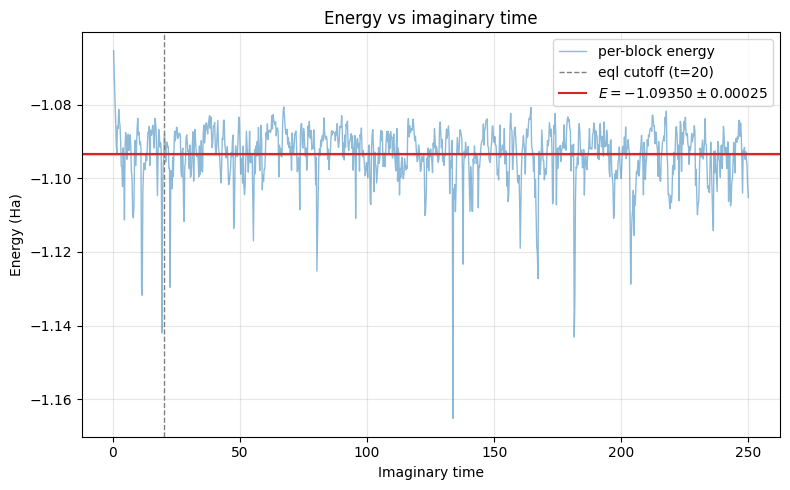

In [12]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weights[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("Energy vs imaginary time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
from afqmc import propagation, prep
from afqmc.sampling import sampler_exp
from afqmc.wavefunctions import wfn_exp, uhf_wfn, ucisd_wfn, ums_wfn
from afqmc.wavefunctions import rhf_wfn, rcisd_wfn, rms_wfn

In [ ]:
wave = wfn_exp.wfn(    
    guide_overlap_fn=rhf_wfn.r_overlap,
    trial_overlap_fn=rhf_wfn.r_overlap,
    force_bias_fn=rhf_wfn.r_force_bias,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=int(ham_data["nchol"]),
    nchol_chunk=options["nchol_chunk"],
    )

In [6]:
sampler = sampler_exp(
    options["n_prop_steps"],
    options["n_blocks"],
    n_chol=int(ham_data["nchol"]),
    )

In [ ]:
print("\nEquilibration")

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")


Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430    294.81
 5.00    300.085974      0    300.085974     -1.091241    296.14
10.00    299.704159      0    299.704159     -1.083686    296.30
15.00    299.742647      0    299.742647     -1.086913    296.51
20.00    299.939902      0    299.939902     -1.096461    296.69
25.00    299.968600      0    299.968600     -1.088609    296.86
30.00    299.964905      0    299.964905     -1.092417    297.02
35.00    299.934565      0    299.934565     -1.089787    297.20
40.00    300.024551      0    300.024551     -1.086154    297.34
45.00    300.044119      0    300.044119     -1.093215    297.45
50.00    299.800629      0    299.800629     -1.084109    297.60
55.00    299.973499      0    299.973499     -1.093188    297.77
60.00    300.045332      0    300.045332     -1.097511    297.89
65.00    299.892425      0    299.892425     -1.086333    298.03
70.00    3

E = -1.093498 +/- 0.000247 Ha  (averaged over 921 blocks, t >= 20)


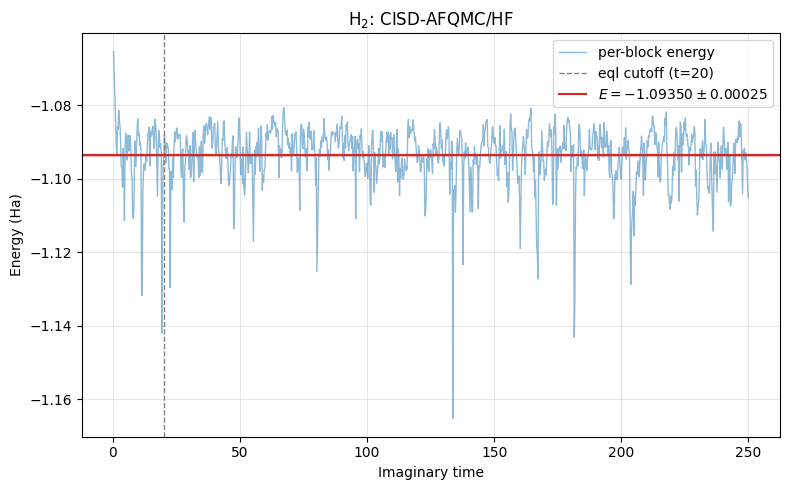

In [20]:
import matplotlib.pyplot as plt

imag_time = np.arange(1, neql_block + 1) * block_time

# --- discard equilibration, keep t >= 20 ---
mask = imag_time >= 20.0
w = weightsp[mask].real
e = energies[mask].real
N = len(e)

# weight-averaged energy
E_mean = np.sum(w * e) / np.sum(w)

# weighted variance (Bessel-corrected) -> std of the mean
wvar = np.sum(w * (e - E_mean) ** 2) / np.sum(w) * N / (N - 1)
sem = np.sqrt(wvar / N)

print(f"E = {E_mean:.6f} +/- {sem:.6f} Ha  (averaged over {N} blocks, t >= 20)")

# --- plot ---
plt.figure(figsize=(8, 5))
plt.plot(imag_time, energies.real, lw=1, alpha=0.5, label="per-block energy")

plt.axvline(20.0, color="gray", ls="--", lw=1, label="eql cutoff (t=20)")
plt.axhline(E_mean, color="C3", lw=1.5,
            label=fr"$E = {E_mean:.5f} \pm {sem:.5f}$")
plt.axhspan(E_mean - sem, E_mean + sem, color="C3", alpha=0.2)

plt.xlabel("Imaginary time")
plt.ylabel("Energy (Ha)")
plt.title("H$_2$: CISD-AFQMC/HF")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
wave = wfn_exp.wfn(    
    guide_overlap_fn=rcisd_wfn.r_overlap,
    force_bias_fn=rcisd_wfn.r_force_bias,
    trial_overlap_fn=rhf_wfn.r_overlap,
    energy_fn=rhf_wfn.r_energy,
    nelec=wave_data["nelec"],
    norb=wave_data["norb"],
    nchol=int(ham_data["nchol"]),
    nchol_chunk=options["nchol_chunk"],
    )

In [8]:
print("\nEquilibration")

init_e = prop_data["e_estimate"]
init_w = np.sum(prop_data["weights"])

print(f"{'inv_T':>5s}  "
      f"{'weight':>12s}  {'killW':>5s}  "
      f"{'weightp':>12s}  {'energy':>12s}  {'runTime':>8s}")

print(f"{0.:5.2f}  "
      f"{init_w:12.6f}  {0:5d}  "
      f"{init_w:12.6f}  {init_e:12.6f}  {time.time() - init_time:8.2f}")


block_time = prop.dt * sampler.n_prop_steps
# neql_block = int(-(-options["eql_time"] // block_time))
neql_block = 1000

weightsp = np.zeros(neql_block, dtype=np.complex128)
energies = np.zeros(neql_block, dtype=np.complex128)

for n in range(1, neql_block+1):
    prop_data, (wt, wp, e) \
        = sampler.block_sample(prop, wave, prop_data, ham_data, wave_data)
    
    weightsp[n-1] = wp
    energies[n-1] = e
    prop_data["e_estimate"] = 0.9 * prop_data["e_estimate"] + 0.1 * e.real
    prop_data["pop_control_ene_shift"] = prop_data["e_estimate"]

    if (n+1) % (min(max(neql_block // 10, 1), 20)) == 0 and n > 0:
        nkill = prop_data["n_killed_walkers"]
        print(f"{(n+1)*block_time:5.2f}  "
              f"{wt.real:12.6f}  {nkill:5d}  "
              f"{wp.real:12.6f}  {e.real:12.6f}  "
              f"{time.time() - init_time:8.2f}")


Equilibration
inv_T        weight  killW       weightp        energy   runTime
 0.00    300.000000      0    300.000000     -1.056430     44.68


KeyError: 'ci1'